Deconvolution Microscopy (Single Channel, Sharded)
==================================================

This example partially replicates a [GlobalBioIm
example](https://biomedical-imaging-group.github.io/GlobalBioIm/examples.html)
using the [microscopy data](http://bigwww.epfl.ch/deconvolution/bio/)
provided by the EPFL Biomedical Imaging Group.

The deconvolution problem is solved using class
[admm.ADMM](../_autosummary/scico.optimize.rst#scico.optimize.ADMM) to
solve an image deconvolution problem with isotropic total variation (TV)
regularization

  $$\mathrm{argmin}_{\mathbf{x}} \; (1/2) \| M (\mathbf{y} - A \mathbf{x})
  \|_2^2 + \lambda \| C \mathbf{x} \|_{2,1} +
  \iota_{\mathrm{NN}}(\mathbf{x}) \;,$$

where $M$ is a mask operator, $A$ is circular convolution,
$\mathbf{y}$ is the blurred image, $C$ is a convolutional gradient
operator, $\iota_{\mathrm{NN}}$ is the indicator function of the
non-negativity constraint, and $\mathbf{x}$ is the deconvolved image.

This example uses array sharding to allow spreading the memory footprint
and computation across multiple GPUs, as opposed to the related
[example script](deconv_microscopy_tv_admm.rst) that does not used array
sharding.

In [1]:
# isort: off
import os

# Configure 4 devices if running on CPU (no effect if GPUs available).
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"
# isort: on

import numpy as np

import jax
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P

import komplot as kplt

import scico.numpy as snp
from scico import functional, linop, loss, util
from scico.examples import downsample_volume, epfl_deconv_data, tile_volume_slices
from scico.numpy.util import pad_to_divisible
from scico.optimize.admm import ADMM, CircularConvolve3DSolver
kplt.config_notebook_plotting()

try:
    import jax_smi

    have_jax_smi = True
except ImportError:
    have_jax_smi = False

Get and preprocess data. The data may be downsampled to limit the memory
requirements and run time of the example. Reducing the downsampling rate
will make the example slower and more memory-intensive. To run this
example on a GPU it may be necessary to set environment variables
`XLA_PYTHON_CLIENT_ALLOCATOR=platform` and
`XLA_PYTHON_CLIENT_PREALLOCATE=false`. If your GPUs do not have enough
memory, try setting the environment variable `JAX_PLATFORM_NAME=cpu` to
run on CPU.

In [2]:
channel = 0
downsampling_rate = 1

y, psf = epfl_deconv_data(channel, verbose=True)
y = downsample_volume(y, downsampling_rate)
psf = downsample_volume(psf, downsampling_rate)

y -= y.min()
y /= y.max()
psf /= psf.sum()

Pad data to avoid boundary artifacts and create mask.

In [3]:
padding = [[0, p] for p in np.array(psf.shape) - 1]
y_pad = np.pad(y, padding)
mask = np.pad(np.ones_like(y), padding)

Further pad arrays to allow for sharding.

In [4]:
num_dev = jax.device_count()
axes = (0, 2)  # Axis 2 included because the CircularConvolve3D FFT transposes arrays.
divisors = (num_dev, num_dev)
y_pad, _ = pad_to_divisible(y_pad, axes, divisors)
mask, _ = pad_to_divisible(mask, axes, divisors)
psf, _ = pad_to_divisible(psf, axes, divisors)

Create mesh and sharding and sharded jax arrays.

In [5]:
mesh = jax.make_mesh(
    (num_dev, 1),
    ("a", "b"),
    axis_types=(
        AxisType.Auto,
        AxisType.Auto,
    ),
)
shard = NamedSharding(mesh, P("a"))

# If jax_smi module installed, initialize it to allow memory usage tracking
# using jax-smi.
if have_jax_smi:
    jax_smi.initialise_tracking()

y_pad = jax.device_put(y_pad, shard)
mask = jax.device_put(mask, shard)
psf = jax.device_put(psf, shard)

Define problem and algorithm parameters.

In [6]:
λ = 2e-6  # ℓ1 norm regularization parameter
ρ0 = 1e-3  # ADMM penalty parameter for first auxiliary variable
ρ1 = 1e-3  # ADMM penalty parameter for second auxiliary variable
ρ2 = 1e-3  # ADMM penalty parameter for third auxiliary variable
maxiter = 100  # number of ADMM iterations

Create operators.

In [7]:
M = linop.Diagonal(mask)
C0 = linop.CircularConvolve3D(h=psf, input_shape=mask.shape, h_center=np.array(psf.shape) / 2 - 0.5)
C1 = linop.FiniteDifference(input_shape=mask.shape, circular=True)
C2 = linop.Identity(mask.shape)

Create functionals.

In [8]:
g0 = loss.SquaredL2Loss(y=y_pad, A=M)  # loss function (forward model)
g1 = λ * functional.L21Norm()  # TV penalty (when applied to gradient)
g2 = functional.NonNegativeIndicator()  # non-negativity constraint

Set up ADMM solver object and solve problem.

In [9]:
solver = ADMM(
    f=None,
    g_list=[g0, g1, g2],
    C_list=[C0, C1, C2],
    rho_list=[ρ0, ρ1, ρ2],
    maxiter=maxiter,
    itstat_options={"display": True, "period": 10},
    x0=y_pad,
    subproblem_solver=CircularConvolve3DSolver(shard),
)

print("Solving on %s\n" % util.device_info(shard))
x_pad = solver.solve()
solve_stats = solver.itstat_object.history(transpose=True)
x = np.array(x_pad)[: y.shape[0], : y.shape[1], : y.shape[2]]

Solving on 
GPU  0  NVIDIA A100-SXM4-80GB
GPU  1  NVIDIA A100-SXM4-80GB
GPU  2  NVIDIA A100-SXM4-80GB
GPU  3  NVIDIA A100-SXM4-80GB
GPU  4  NVIDIA A100-SXM4-80GB
GPU  5  NVIDIA A100-SXM4-80GB
GPU  6  NVIDIA A100-SXM4-80GB
GPU  7  NVIDIA A100-SXM4-80GB



Iter  Time      Objective  Prml Rsdl  Dual Rsdl
-----------------------------------------------
   0  6.23e+01  1.789e+00  2.409e+01  5.340e-01


  10  6.52e+01  5.190e+00  4.950e+00  3.260e-01


  20  6.70e+01  5.951e+00  6.505e+00  1.475e-01


  30  6.87e+01  7.425e+00  4.176e+00  1.678e-01


...

  60  7.41e+01  1.288e+01  2.973e+00  1.086e-01


  70  7.58e+01  1.482e+01  2.858e+00  8.360e-02


  80  7.76e+01  1.689e+01  2.267e+00  8.662e-02


  90  7.94e+01  1.900e+01  2.429e+00  6.686e-02


  99  8.10e+01  2.098e+01  2.163e+00  6.623e-02


Show the recovered image.

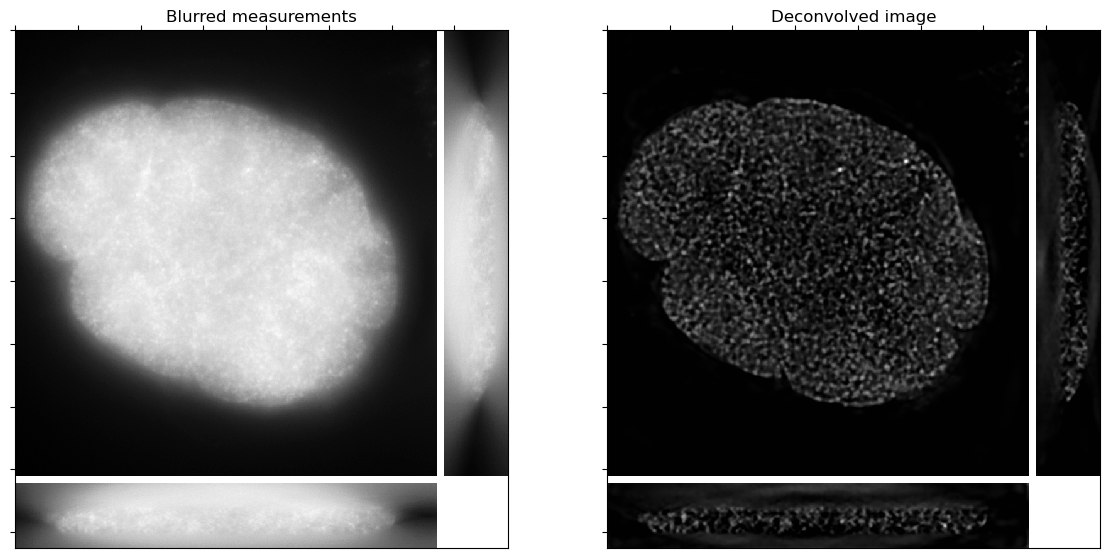

In [10]:
fig, ax = kplt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=(14, 7))
kplt.imview(tile_volume_slices(y), title="Blurred measurements", ax=ax[0])
kplt.imview(tile_volume_slices(x), title="Deconvolved image", ax=ax[1])
fig.show()

Plot convergence statistics.

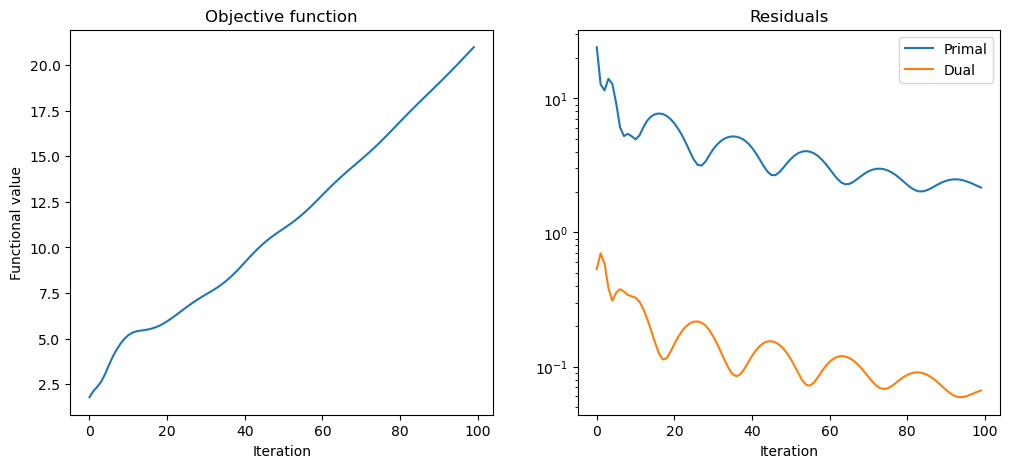

In [11]:
fig, ax = kplt.subplots(nrows=1, ncols=2, figsize=(12, 5))
kplt.plot(
    solve_stats.Objective,
    title="Objective function",
    xlabel="Iteration",
    ylabel="Functional value",
    ax=ax[0],
)
kplt.plot(
    snp.array((solve_stats.Prml_Rsdl, solve_stats.Dual_Rsdl)).T,
    ylog=True,
    title="Residuals",
    xlabel="Iteration",
    legend=("Primal", "Dual"),
    ax=ax[1],
)
fig.show()